<a href="https://colab.research.google.com/github/katydixonx/CSCU9M6_Assignment/blob/main/CSCU9M6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSCU9M6 Sign Language Recognition Using Deep Convolutional Neural Networks
**Student number:** 3140669
**March 2026**
**GitHub:** https://github.com/katydixonx/CSCU9M6_Assignment

## 1. Setup and Imports

In [12]:
# Import all required libraries

import numpy as np          # numerical operations and array manipulation
import pandas as pd         # loading and inspecting CSV files
import matplotlib.pyplot as plt  # plotting graphs and images
import tensorflow as tf     # deep learning framework
from tensorflow import keras  # high-level neural network API

from sklearn.model_selection import train_test_split  # creating validation split
from sklearn.preprocessing import LabelEncoder        # encoding labels

# Print versions so the marker can see your environment
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.19.0
NumPy version: 2.0.2


## 2. Mount Google Drive and Load Dataset

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Deliverable 1: Data Loading and Preprocessing

### 1.1 Load the Dataset

In [14]:
# DELIVERABLE 1.1 - Load CSV files

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('/content/drive/MyDrive/SignLanguageMNIST/sign_mnist_train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/SignLanguageMNIST/sign_mnist_test.csv')


In [15]:
# Inspect the class distribution

# Count how many images per class in training set
print("=== Class Distribution in Training Set ===")
print(train_df['label'].value_counts().sort_index())

# Check unique label values
unique_labels = sorted(train_df['label'].unique())
print("\nUnique label values:", unique_labels)
print("Number of classes:", len(unique_labels))


=== Class Distribution in Training Set ===
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

Unique label values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Number of classes: 24


In [16]:
# DELIVERABLE 1.1 - Separate labels from pixel values
# reshape into (28, 28, 1) image tensors

# --- Training data ---
y_train_full = train_df['label'].values
x_train_full = train_df.drop('label', axis=1).values
# --- Test data ---
y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values


x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test        = x_test.reshape(-1, 28, 28, 1)

print("x_train_full shape:", x_train_full.shape)  # (27455, 28, 28, 1)
print("y_train_full shape:", y_train_full.shape)   # (27455,)
print("x_test shape:", x_test.shape)               # (7172, 28, 28, 1)
print("y_test shape:", y_test.shape)               # (7172,)


x_train_full shape: (27455, 28, 28, 1)
y_train_full shape: (27455,)
x_test shape: (7172, 28, 28, 1)
y_test shape: (7172,)


### 1.2 Normalise Pixel Values


In [17]:
# Convert integer pixel values (0-255) to float32 and scale to [0.0, 1.0]
x_train_full = x_train_full.astype("float32") / 255.0
x_test        = x_test.astype("float32") / 255.0

# Verify the normalisation worked
print("Pixel value BEFORE normalisation would be: 0 to 255")
print("Pixel value AFTER normalisation:")
print("  Minimum value in training set:", x_train_full.min())   # should be 0.0
print("  Maximum value in training set:", x_train_full.max())   # should be 1.0
print("  Data type:", x_train_full.dtype)                       # should be float32


Pixel value BEFORE normalisation would be: 0 to 255
Pixel value AFTER normalisation:
  Minimum value in training set: 0.0
  Maximum value in training set: 1.0
  Data type: float32


### 1.3 Validation Split

In [18]:
# Split 20% of training data into a validation set
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,       # 20% goes to validation
    random_state=42,     # ensures same split every run
    stratify=y_train_full  # keeps class proportions balanced in both sets
)

print("=== Dataset Split Summary ===")
print(f"Training samples:   {x_train.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")
print(f"Test samples:       {x_test.shape[0]}")
print(f"\nImage shape: {x_train.shape[1:]}")


=== Dataset Split Summary ===
Training samples:   21964
Validation samples: 5491
Test samples:       7172

Image shape: (28, 28, 1)


In [19]:
num_classes = 24   # 24 ASL letters (A-Y, excluding J and Z)

y_train_oh = tf.one_hot(y_train, depth=num_classes)
y_val_oh   = tf.one_hot(y_val,   depth=num_classes)
y_test_oh  = tf.one_hot(y_test,  depth=num_classes)

print("y_train_oh shape:", y_train_oh.shape)   # (21964, 24)
print("\nExample — label 0 (letter A) encoded as:")
print(y_train_oh[0].numpy())   # [1. 0. 0. 0. 0. ... 0.]


y_train_oh shape: (21964, 24)

Example — label 0 (letter A) encoded as:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


### 1.4 Visualise Sample Images

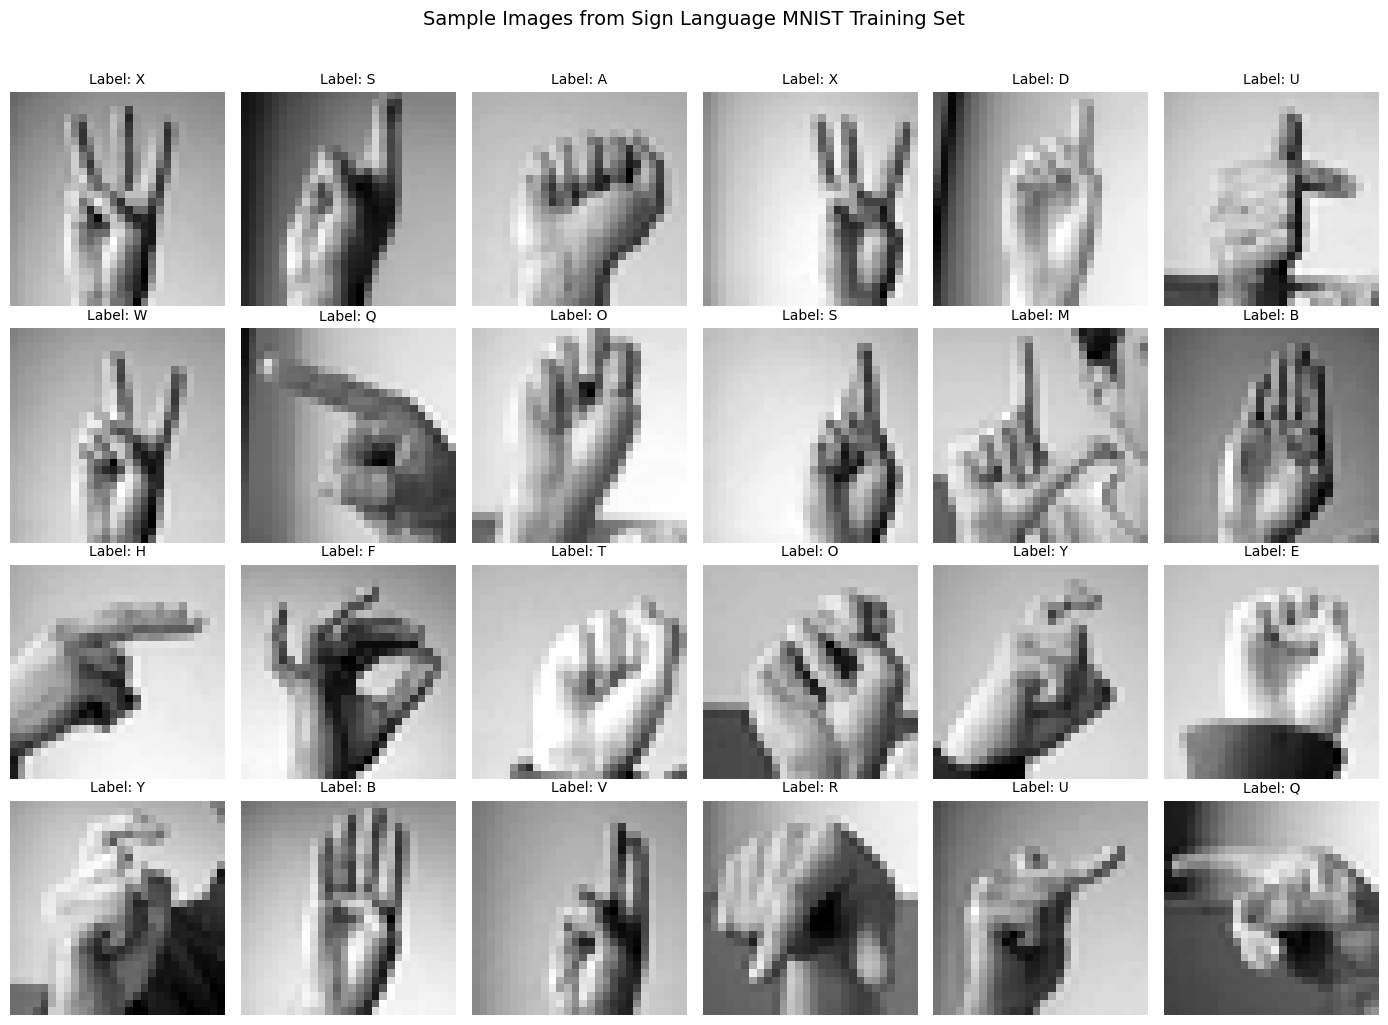

Image saved as 'sample_images.png'


In [20]:
# Map numeric labels back to letters
all_letters = [chr(65 + i) for i in range(26) if chr(65 + i) not in ['J', 'Z']]
label_to_letter = {i: letter for i, letter in enumerate(all_letters)}

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
axes = axes.flat

for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')   # reshape back to 2D for display
    ax.set_title(f"Label: {label_to_letter[y_train[i]]}", fontsize=10)
    ax.axis('off')   # hide axis tick marks

plt.suptitle("Sample Images from Sign Language MNIST Training Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')  # save for your report
plt.show()

print("Image saved as 'sample_images.png'")


In [21]:
# Final summary of preprocessed data

print("=" * 50)
print("DELIVERABLE 1 COMPLETE — DATA SUMMARY")
print("=" * 50)
print(f"\nTraining set:   {x_train.shape}  labels: {y_train.shape}")
print(f"Validation set: {x_val.shape}  labels: {y_val.shape}")
print(f"Test set:       {x_test.shape}  labels: {y_test.shape}")
print(f"\nOne-hot labels shape:  {y_train_oh.shape}")
print(f"Pixel value range:     [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Data type:             {x_train.dtype}")
print(f"Number of classes:     {num_classes}")
print("\nReady for Deliverable 2: CNN Architecture")


DELIVERABLE 1 COMPLETE — DATA SUMMARY

Training set:   (21964, 28, 28, 1)  labels: (21964,)
Validation set: (5491, 28, 28, 1)  labels: (5491,)
Test set:       (7172, 28, 28, 1)  labels: (7172,)

One-hot labels shape:  (21964, 24)
Pixel value range:     [0.0, 1.0]
Data type:             float32
Number of classes:     24

Ready for Deliverable 2: CNN Architecture
